# Chapter 9: Portfolio Theory

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Covariance, correlation, and diversification
2. Two-asset portfolio variance
3. N-asset matrix notation
4. Minimum-variance and maximum-Sharpe portfolios
5. Risk-return utility

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 9.1 Correlated Return Series

Correlation is a unit-free measure of co-movement. The lecture construction creates two normal series with a target correlation.


### Structured Review

- **Data source:** Record where the observations come from and whether the example is online, local, or simulated.
- **Cleaning:** Inspect missing values, data types, date order, and duplicated observations before calculating returns.
- **Transformation:** Use adjacent prices for one-period returns and compounding for multi-period returns.
- **Storage:** Choose CSV for portability and pickle only for trusted Python workflows that need preserved data types.

### Formula and Workflow

1. Sort observations by date.
2. Clean the price series without inventing unsupported returns.
3. Calculate simple or log returns.
4. Aggregate with products of growth factors or sums of log returns.
5. Validate one observation manually.

### Exam Focus

- Complete `P_t / P_(t-1) - 1`, `log(P_t/P_(t-1))`, and `prod(1+R)-1`.
- Distinguish price filling from return filling.
- Explain why averaging daily returns is not the exact monthly return.

### Common Mistakes

- Calculating returns on unsorted dates.
- Keeping the first missing return in a statistical test.
- Treating a percentage value as if it were already a decimal.


In [1]:
import numpy as np

rng = np.random.default_rng(123456)
n = 5000
target_correlation = 0.30
x1 = rng.standard_normal(n)
x2 = rng.standard_normal(n)

# y2 将共同冲击与独立冲击组合，理论相关系数为 rho
y1 = x1
y2 = target_correlation * x1 + np.sqrt(1 - target_correlation**2) * x2

covariance = np.cov(y1, y2, ddof=1)[0, 1]
correlation = np.corrcoef(y1, y2)[0, 1]
print("Sample covariance =", round(float(covariance), 4))
print("Sample correlation =", round(float(correlation), 4))


Sample covariance = 0.3089
Sample correlation = 0.3061


**Result interpretation.** The sample correlation should be close to 0.30; small differences are sampling noise.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 9.2 Two-Asset Portfolio Risk

Portfolio variance contains two individual variance terms and one covariance term. Lower correlation creates a stronger diversification benefit.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [2]:
import numpy as np

def two_asset_volatility(weight_a, vol_a, vol_b, correlation):
    weight_b = 1 - weight_a
    covariance = correlation * vol_a * vol_b
    variance = (
        weight_a**2 * vol_a**2
        + weight_b**2 * vol_b**2
        + 2 * weight_a * weight_b * covariance
    )
    return np.sqrt(variance)

weight_a, vol_a, vol_b = 0.60, 0.20, 0.12
for rho in (1.0, 0.3, -0.3):
    # 相关系数下降时，组合波动率通常下降
    risk = two_asset_volatility(weight_a, vol_a, vol_b, rho)
    print(f"rho={rho:+.1f}: portfolio volatility={risk:.2%}")


rho=+1.0: portfolio volatility=16.80%
rho=+0.3: portfolio volatility=14.20%
rho=-0.3: portfolio volatility=11.51%


**Result interpretation.** The same assets and weights produce less portfolio risk when their correlation is lower.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

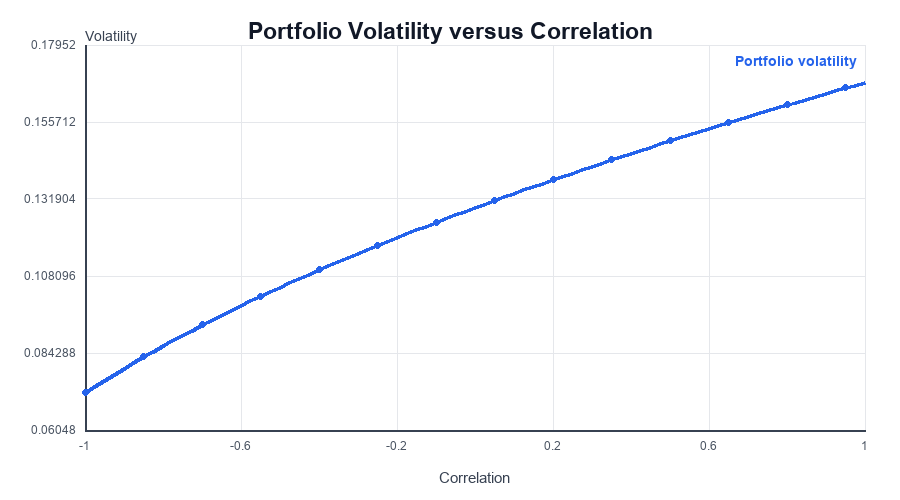


## 9.3 N-Asset Portfolio in Matrix Form

For weights w and covariance matrix Sigma, expected return is w' mu and variance is w' Sigma w.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [3]:
import numpy as np

expected_returns = np.array([0.08, 0.11, 0.06])
volatilities = np.array([0.16, 0.22, 0.10])
correlations = np.array([
    [1.00, 0.45, 0.20],
    [0.45, 1.00, 0.10],
    [0.20, 0.10, 1.00],
])
weights = np.array([0.40, 0.35, 0.25])

# 协方差矩阵 = 相关系数矩阵 × 两侧标准差
covariance = np.outer(volatilities, volatilities) * correlations
portfolio_return = weights @ expected_returns
portfolio_variance = weights @ covariance @ weights

print("Weights sum =", round(float(weights.sum()), 6))
print("Expected return =", round(float(portfolio_return), 4))
print("Volatility =", round(float(np.sqrt(portfolio_variance)), 4))


Weights sum = 1.0
Expected return = 0.0855
Volatility = 0.1269


**Result interpretation.** Matrix notation scales the two-asset formula to any number of assets.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 9.4 Constrained Portfolio Optimization

SLSQP can enforce full investment and long-only bounds while minimizing variance or maximizing the Sharpe ratio.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [4]:
import numpy as np
from scipy.optimize import minimize

mu = np.array([0.08, 0.11, 0.06])
covariance = np.array([
    [0.0256, 0.01584, 0.0032],
    [0.01584, 0.0484, 0.0022],
    [0.0032, 0.0022, 0.0100],
])
risk_free = 0.025
n_assets = len(mu)

def variance(weights):
    return weights @ covariance @ weights

def negative_sharpe(weights):
    portfolio_return = weights @ mu
    portfolio_volatility = np.sqrt(variance(weights))
    return -(portfolio_return - risk_free) / portfolio_volatility

# 等式约束要求权重之和为 1；bounds 禁止卖空
constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
bounds = [(0, 1)] * n_assets
initial = np.full(n_assets, 1 / n_assets)

minimum_variance = minimize(variance, initial, method="SLSQP", bounds=bounds, constraints=constraints)
maximum_sharpe = minimize(negative_sharpe, initial, method="SLSQP", bounds=bounds, constraints=constraints)

print("Minimum-variance weights =", np.round(minimum_variance.x, 4))
print("Maximum-Sharpe weights =", np.round(maximum_sharpe.x, 4))
print("Maximum Sharpe =", round(float(-maximum_sharpe.fun), 4))


Minimum-variance weights = [0.1793 0.0766 0.7441]
Maximum-Sharpe weights = [0.189  0.2518 0.5592]
Maximum Sharpe = 0.5159


**Result interpretation.** The two objectives generally select different portfolios because minimum variance ignores expected return.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

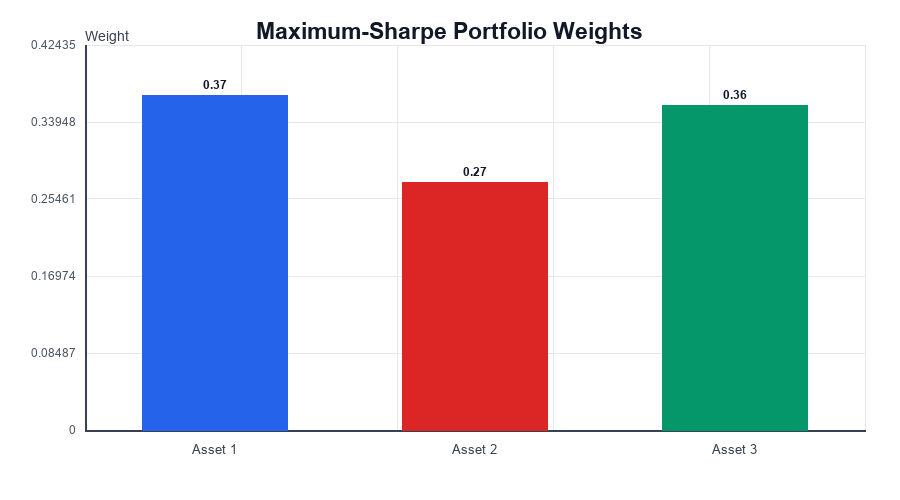


## 9.5 Risk-Return Utility

A mean-variance investor can summarize preference with U = E(R) - 0.5 A sigma-squared, where A measures risk aversion.


### Structured Review

- **Data source:** Record where the observations come from and whether the example is online, local, or simulated.
- **Cleaning:** Inspect missing values, data types, date order, and duplicated observations before calculating returns.
- **Transformation:** Use adjacent prices for one-period returns and compounding for multi-period returns.
- **Storage:** Choose CSV for portability and pickle only for trusted Python workflows that need preserved data types.

### Formula and Workflow

1. Sort observations by date.
2. Clean the price series without inventing unsupported returns.
3. Calculate simple or log returns.
4. Aggregate with products of growth factors or sums of log returns.
5. Validate one observation manually.

### Exam Focus

- Complete `P_t / P_(t-1) - 1`, `log(P_t/P_(t-1))`, and `prod(1+R)-1`.
- Distinguish price filling from return filling.
- Explain why averaging daily returns is not the exact monthly return.

### Common Mistakes

- Calculating returns on unsorted dates.
- Keeping the first missing return in a statistical test.
- Treating a percentage value as if it were already a decimal.


In [5]:
portfolios = [
    {"name": "Conservative", "return": 0.065, "volatility": 0.08},
    {"name": "Balanced", "return": 0.090, "volatility": 0.14},
    {"name": "Aggressive", "return": 0.125, "volatility": 0.24},
]

for risk_aversion in (2, 6):
    utilities = []
    for portfolio in portfolios:
        # A 越大，波动率平方受到的惩罚越重
        utility = portfolio["return"] - 0.5 * risk_aversion * portfolio["volatility"]**2
        utilities.append((utility, portfolio["name"]))
    best = max(utilities)
    print(f"A={risk_aversion}: preferred={best[1]}, utility={best[0]:.4f}")


A=2: preferred=Balanced, utility=0.0704
A=6: preferred=Conservative, utility=0.0458


**Result interpretation.** More risk-averse investors assign a larger penalty to volatility and may prefer a lower-risk portfolio.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
